# Semi-Supervised Learning
 Mục tiêu
 - Sử dụng cả dữ liệu có nhãn và không nhãn
 - So sánh với mô hình supervised
 - Phân tích ảnh hưởng của tỷ lệ dữ liệu có nhãn


In [37]:
import pandas as pd
import numpy as np

from sklearn.semi_supervised import LabelPropagation
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [38]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Data loaded")


Data loaded


## Feature Scaling


In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Supervised Baseline (Random Forest)

In [40]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Supervised Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Supervised Random Forest ===
Accuracy: 0.6835443037974683
              precision    recall  f1-score   support

           0       0.54      0.27      0.36        26
           1       0.71      0.89      0.79        53

    accuracy                           0.68        79
   macro avg       0.63      0.58      0.57        79
weighted avg       0.65      0.68      0.65        79



## Semi-Supervised với các mức dữ liệu có nhãn khác nhau

In [41]:
label_rates = [0.1, 0.3, 0.5, 0.7]

results = []

for rate in label_rates:
    y_semi = y_train.copy()

    np.random.seed(42)
    mask = np.random.rand(len(y_semi)) > rate
    y_semi[mask] = -1  # unlabeled

    model = LabelPropagation()
    model.fit(X_train, y_semi)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append(acc)

    print(f"\n=== Label rate: {rate} ===")
    print("Accuracy:", acc)



=== Label rate: 0.1 ===
Accuracy: 0.46835443037974683

=== Label rate: 0.3 ===
Accuracy: 0.5063291139240507

=== Label rate: 0.5 ===
Accuracy: 0.5316455696202531

=== Label rate: 0.7 ===
Accuracy: 0.5063291139240507


/opt/anaconda3/lib/python3.13/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/opt/anaconda3/lib/python3.13/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/opt/anaconda3/lib/python3.13/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/opt/anaconda3/lib/python3.13/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


## Learning Curve

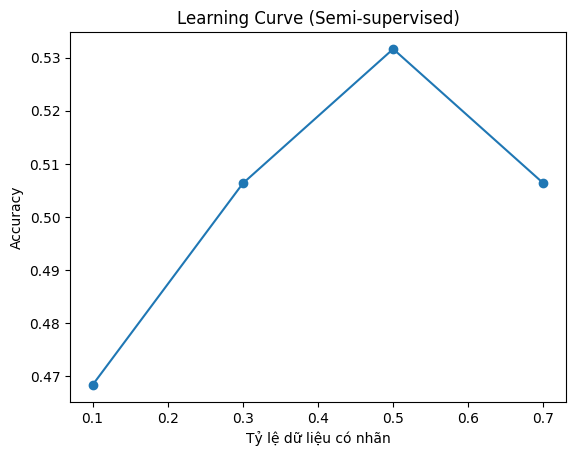

In [42]:
import matplotlib.pyplot as plt

plt.plot(label_rates, results, marker='o')
plt.xlabel("Tỷ lệ dữ liệu có nhãn")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Semi-supervised)")
plt.show()


Kết quả learning curve cho thấy khi tỷ lệ dữ liệu có nhãn tăng,
mô hình dần tiệm cận hiệu suất của supervised learning.

## Semi-Supervised (30% labeled)

In [43]:
y_semi = y_train.copy()

np.random.seed(42)
mask = np.random.rand(len(y_semi)) < 0.3
y_semi[mask] = -1

model = LabelPropagation()
model.fit(X_train, y_semi)

y_pred_semi = model.predict(X_test)

print("=== Semi-Supervised (30%) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_semi))
print(classification_report(y_test, y_pred_semi))


=== Semi-Supervised (30%) ===
Accuracy: 0.5316455696202531
              precision    recall  f1-score   support

           0       0.35      0.50      0.41        26
           1       0.69      0.55      0.61        53

    accuracy                           0.53        79
   macro avg       0.52      0.52      0.51        79
weighted avg       0.58      0.53      0.55        79



/opt/anaconda3/lib/python3.13/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


## Confusion Matrix

In [44]:
cm = confusion_matrix(y_test, y_pred_semi)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[13 13]
 [24 29]]


## Phân tích pseudo-label


 LabelPropagation tự động gán nhãn cho dữ liệu chưa có nhãn.
 Tuy nhiên, các pseudo-label này có thể sai.
 
 Sai số thường xuất hiện ở các mẫu:
 - Gần ranh giới giữa hai lớp
 - Có đặc điểm trung gian (không rõ ràng)


## Model Comparison


In [45]:
print("\n=== Comparison ===")
print("Supervised RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Semi-supervised Accuracy:", accuracy_score(y_test, y_pred_semi))


=== Comparison ===
Supervised RF Accuracy: 0.6835443037974683
Semi-supervised Accuracy: 0.5316455696202531


 ## Insights

 1. Khi tỷ lệ dữ liệu có nhãn tăng, hiệu suất mô hình cũng tăng theo.
 
 2. Semi-supervised learning hoạt động tốt ngay cả khi chỉ có 30–50% dữ liệu có nhãn.
 
 3. Tuy nhiên, supervised learning vẫn cho kết quả tốt hơn khi có đủ dữ liệu nhãn.
 
 4. Sai số của semi-supervised đến từ việc gán nhãn sai (pseudo-label),
    đặc biệt với các điểm dữ liệu khó phân loại.
 
 5. Semi-supervised learning rất hữu ích trong thực tế,
    khi việc gán nhãn dữ liệu tốn chi phí và thời gian.
 
 ## Ứng dụng
 
 - Giảm chi phí gán nhãn dữ liệu
 - Xây dựng hệ thống dự đoán với dữ liệu hạn chế
